### Checkpoint

#### 钩子 Hook 的应用：记录保存的残差的形状和数量

In [2]:
import torch
from cs336_basics.model import RMSNorm

x = torch.randn((4, 512, 2560), requires_grad = True)

def pack_hook(t):
    shape, dtype, grad_fn = t.shape, t.dtype, t.grad_fn
    print(f"Saving residual: {shape=}, {dtype=}, {grad_fn=}")
    return t

def unpack_hook(t):
    shape, dtype, grad_fn = t.shape, t.dtype, t.grad_fn
    print(f"Loading residual: {shape=}, {dtype=}, {grad_fn=}")
    return t

In [3]:
ln1= RMSNorm(x.shape[-1])

with torch.autograd.graph.saved_tensors_hooks(pack_hook, unpack_hook):
    y = ln1(x)
    y.sum().backward()

Saving residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=<SqrtBackward0 object at 0x114af5720>
Saving residual: shape=torch.Size([2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=<SqrtBackward0 object at 0x114af5720>
Saving residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=<MulBackward0 object at 0x114af5720>
Loading residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=<SqrtBackward0 object at 0x11508eb60>
Loading residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=<MulBackward0 object at 0x11508eb60>
Loading residual: shape=torch.Size([2560]), dtype=torch.float32, grad_fn=None
Loading residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
Loading 

In [6]:
# 采用 torch.compile：仅保存了输入(x, gains)和输出(out)
# 初次运行代码需要编译，所以运行时间长；之后就会迅速
ln2 = torch.compile(RMSNorm(x.shape[-1]))

with torch.autograd.graph.saved_tensors_hooks(pack_hook, unpack_hook):
    y = ln2(x)
    y.sum().backward()

Saving residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=None
Loading residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
Loading residual: shape=torch.Size([2560]), dtype=torch.float32, grad_fn=None
Loading residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=None


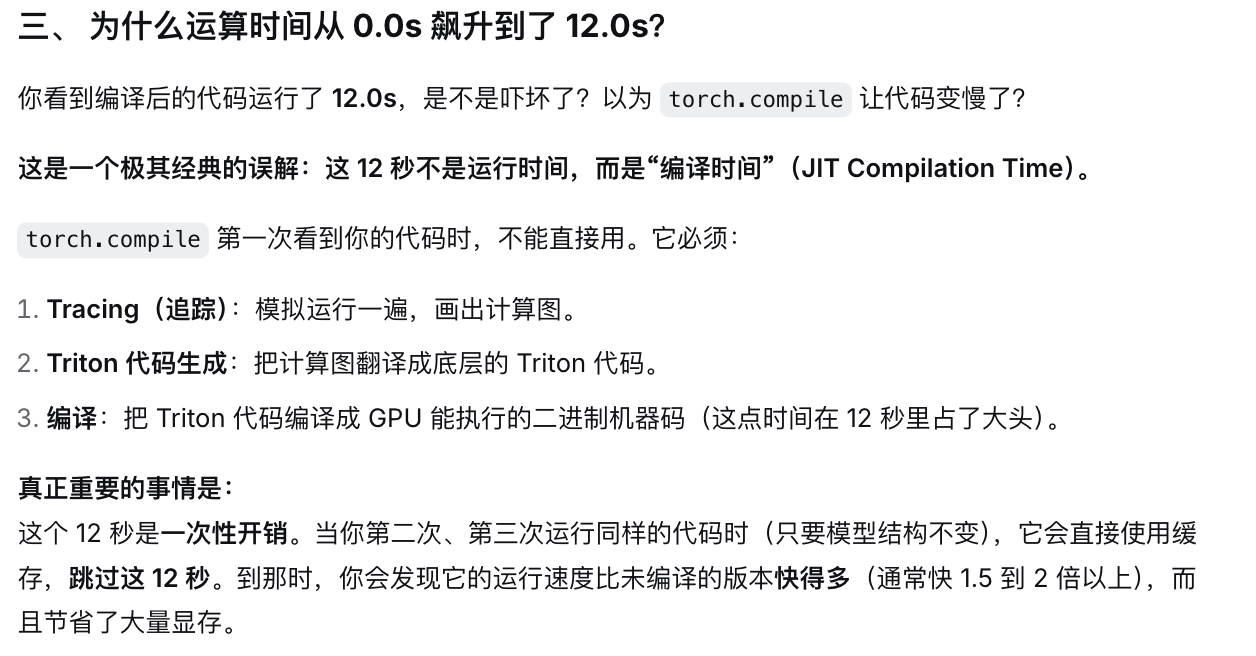

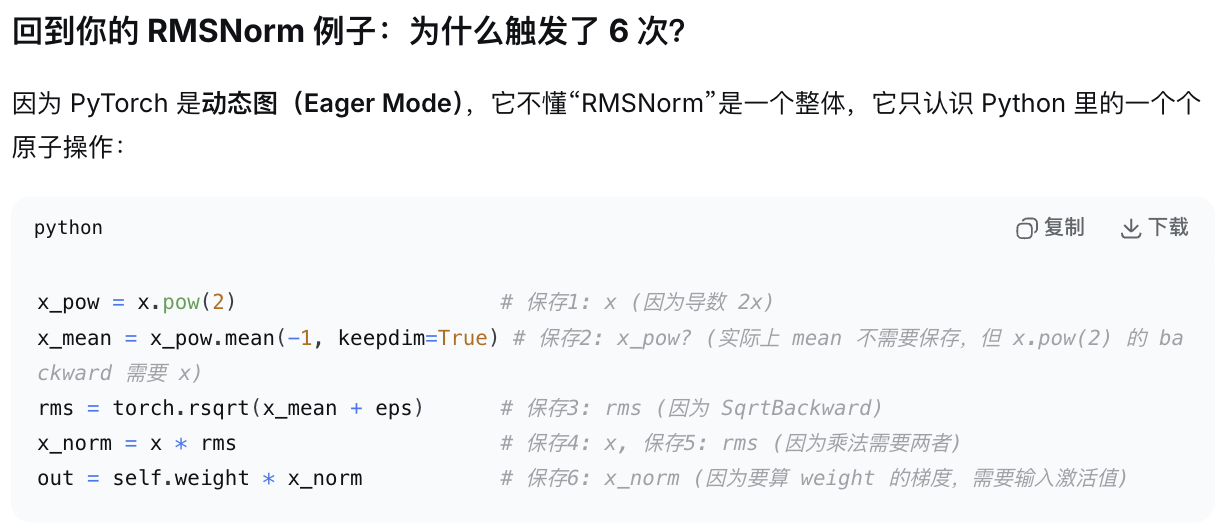

#### 算子融合 Operator Fusion

In [1]:
import torch
from cs336_basics.model import RoPE, TransformerBlock

# num_layers for this model is 32
d_model, d_ff, num_heads, context_length = 2560, 10240, 16, 2048
block = TransformerBlock(d_model=d_model, d_ff=d_ff, num_heads=num_heads, max_seq_len=context_length)

# Fuse as much torch.compile will allow
block = torch.compile(block, fullgraph=True)
x = torch.randn(4, context_length, d_model, requires_grad=True)

# Now logs the number of bytes saved
total_size_bytes = 0
def pack_hook(t):
    if isinstance(t, torch.nn.Parameter):  # Skip logging parameters to avoid double counting
        return t
    global total_size_bytes
    shape, dtype, grad_fn = t.shape, t.dtype, t.grad_fn
    total_size_bytes += t.numel() * t.element_size()
    print(f"Saving residual: {shape=}, {dtype=}, {grad_fn=}")
    return t

def unpack_hook(t):
    shape, dtype, grad_fn = t.shape, t.dtype, t.grad_fn
    print(f"Loading residual: {shape=}, {dtype=}, {grad_fn=}")
    return t

In [1]:
# Run forward pass, saving for backward
with torch.autograd.graph.saved_tensors_hooks(pack_hook, unpack_hook):
    y = block(x)

print(f"Total size of saved tensors in single TransformerBlock: {total_size_bytes / (1024**2):.2f} MiB")

Saving residual: shape=torch.Size([4, 2048, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([2048, 80]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([2048, 80]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 2048, 1]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 2048, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([64, 2048, 2048]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([2048, 2048]), dtype=torch.bool, grad_fn=None
Saving residual: shape=torch.Size([4, 16, 2048, 1]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 16, 2048, 1]), dtype=torch.int64, grad_fn=None
Saving residual: shape=torch.Size([4, 16, 2048, 1]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 16, 2048, 2048]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([1, 8192, 2560]), dtype=torch.flo

#### 激活检查点 Activation Checkpointing

核心思想就是不保存中间激活值。在前向传播时只保存“边界”（比如每一层的输入），在反向传播时，重新计算前向传播（Recomputation）来获取需要的中间值，以此用计算换显存。

In [3]:
def four_blocks(x):
    x = block(x)
    x = block(x)
    x = block(x)
    x = block(x)
    return x

with torch.autograd.graph.saved_tensors_hooks(pack_hook, unpack_hook):
    y = four_blocks(x)

print(f"Total size of saved tensors in four TransformerBlocks: {total_size_bytes / (1024**2):.2f} MiB")

Saving residual: shape=torch.Size([4, 2048, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([2048, 80]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([2048, 80]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 2048, 1]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 2048, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([64, 2048, 2048]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([2048, 2048]), dtype=torch.bool, grad_fn=None
Saving residual: shape=torch.Size([4, 16, 2048, 1]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 16, 2048, 1]), dtype=torch.int64, grad_fn=None
Saving residual: shape=torch.Size([4, 16, 2048, 1]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 16, 2048, 2048]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([1, 8192, 2560]), dtype=torch.flo

In [2]:
from torch.utils.checkpoint import checkpoint

def two_blocks(x):      # x.shape = ([4, 2048, 2560])
    x = block(x)
    x = block(x)
    return x

def four_blocks_checkpoint(x):
    # checkpoint throws out all the saved tensors until the backward pass
    # when getting to the checkpointed block in the backward pass,
    # it reruns a forward pass to produce the saved tensors,
    # then completes normal backward pass.
    x = checkpoint(two_blocks, x, use_reentrant=False)
    x = checkpoint(two_blocks, x, use_reentrant=False)
    return x

with torch.autograd.graph.saved_tensors_hooks(pack_hook, unpack_hook):
    y = four_blocks_checkpoint(x)

print(f"Total size of saved tensors in four TransformerBlocks with checkpointing: {total_size_bytes / (1024**2):.2f} MiB")

Saving residual: shape=torch.Size([0]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 2048, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([0]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 2048, 2560]), dtype=torch.float32, grad_fn=<torch.autograd.function.CompiledFunctionBackward object at 0x11c824050>
Total size of saved tensors in four TransformerBlocks with checkpointing: 160.00 MiB


In [6]:
blocks = []
for _ in range(8):
    blocks.append(block)

def tree_ckpt(blocks, x):
    if len(blocks) == 1:
        return blocks[0](x)
    mid = len(blocks) // 2
    x = checkpoint(tree_ckpt, blocks[:mid], x)   # 递归左子树
    x = checkpoint(tree_ckpt, blocks[mid:], x)   # 递归右子树
    return x

with torch.autograd.graph.saved_tensors_hooks(pack_hook, unpack_hook):
    y = tree_ckpt(blocks, x)

print(f"Total size of saved tensors in four TransformerBlocks with checkpointing: {total_size_bytes / (1024**2):.2f} MiB")

/Users/lucius/projects/personal/cs336作业完成过程/assignments/assignment2-systems/.venv/lib/python3.13/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/Users/lucius/projects/personal/cs336作业完成过程/assignments/assignment2-systems/.venv/lib/python3.13/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass u

Saving residual: shape=torch.Size([4, 2048, 2560]), dtype=torch.float32, grad_fn=None
Saving residual: shape=torch.Size([4, 2048, 2560]), dtype=torch.float32, grad_fn=<torch.autograd.function.CheckpointFunctionBackward object at 0x11da9b250>
Total size of saved tensors in four TransformerBlocks with checkpointing: 640.00 MiB


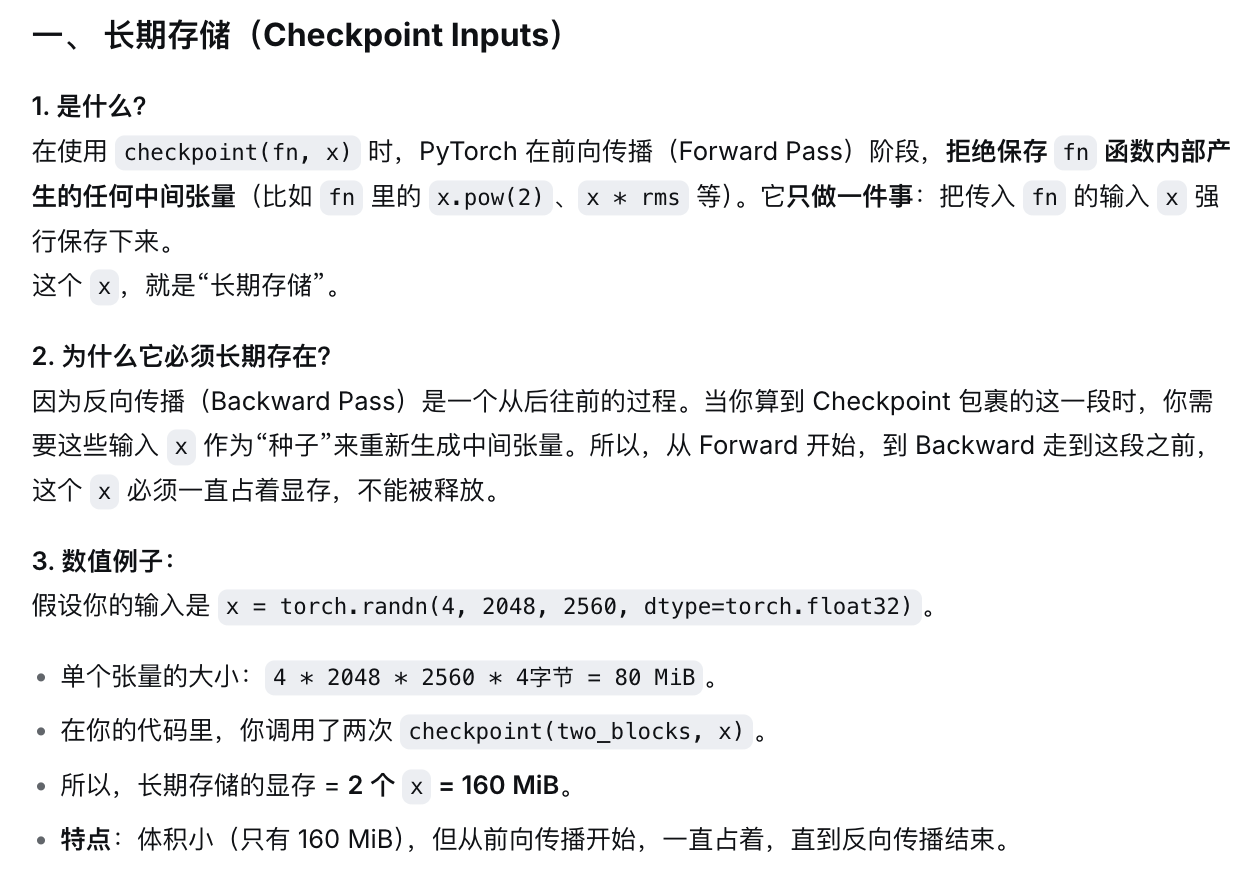
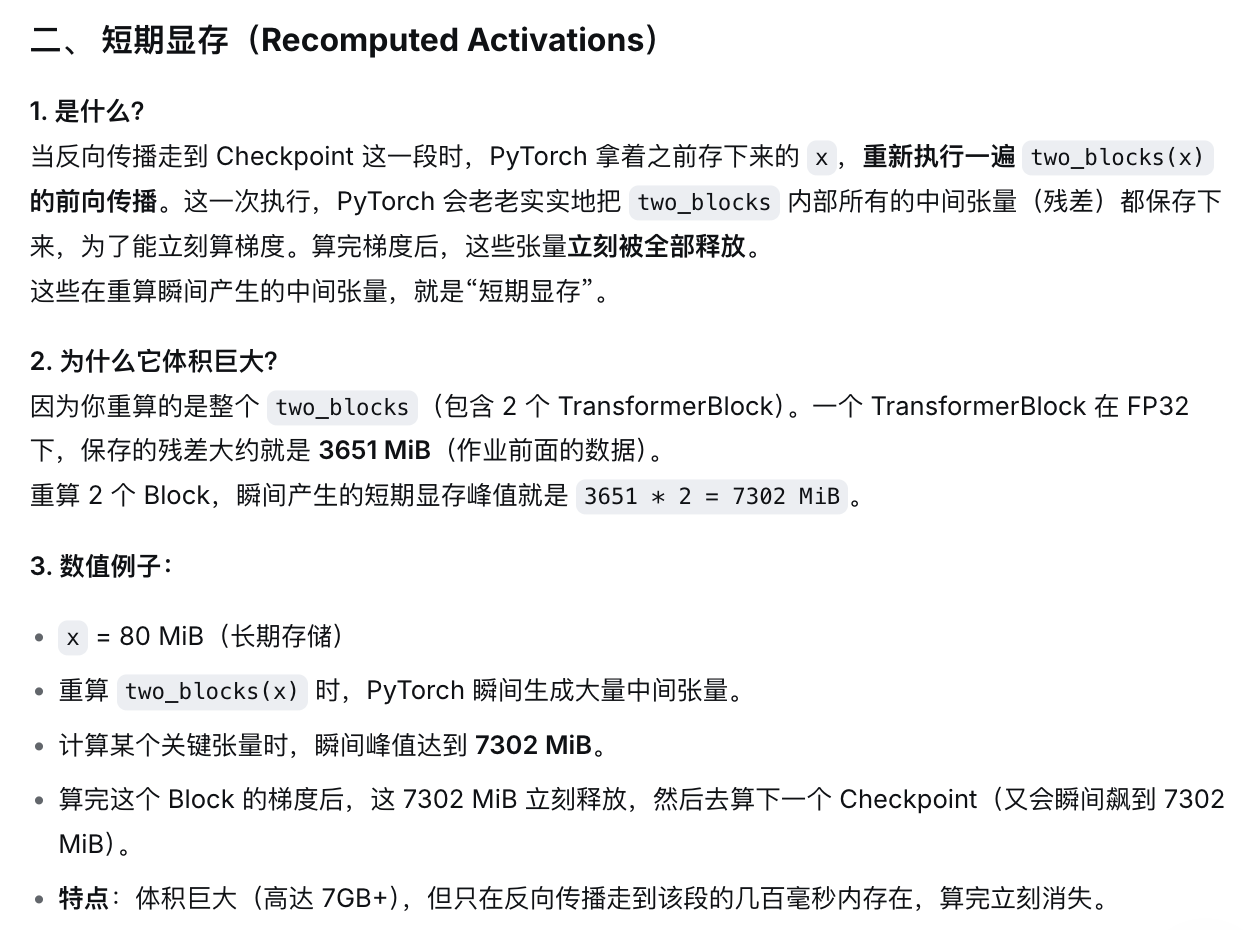
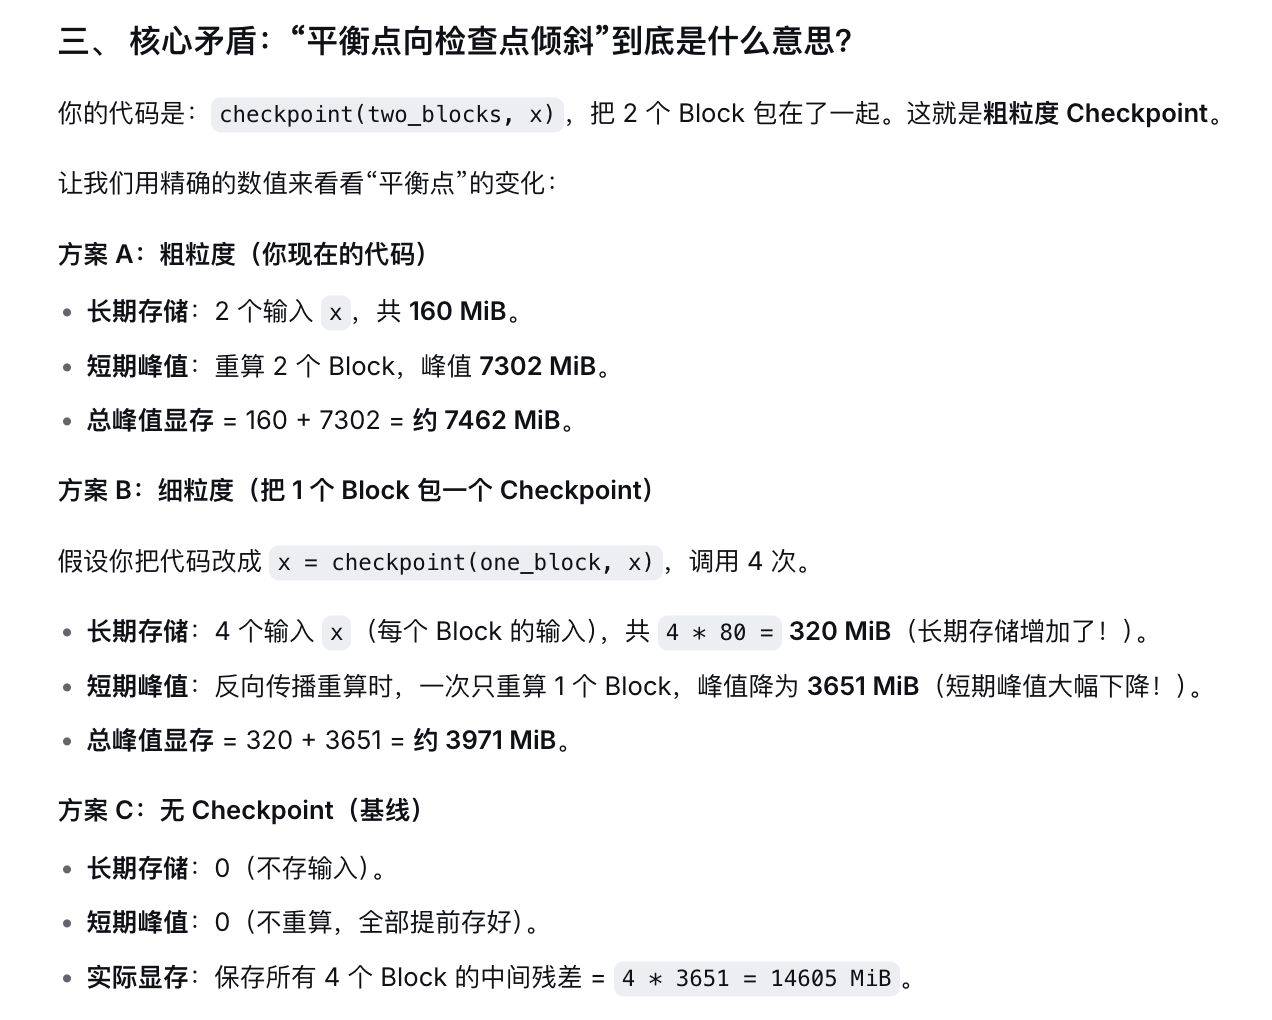

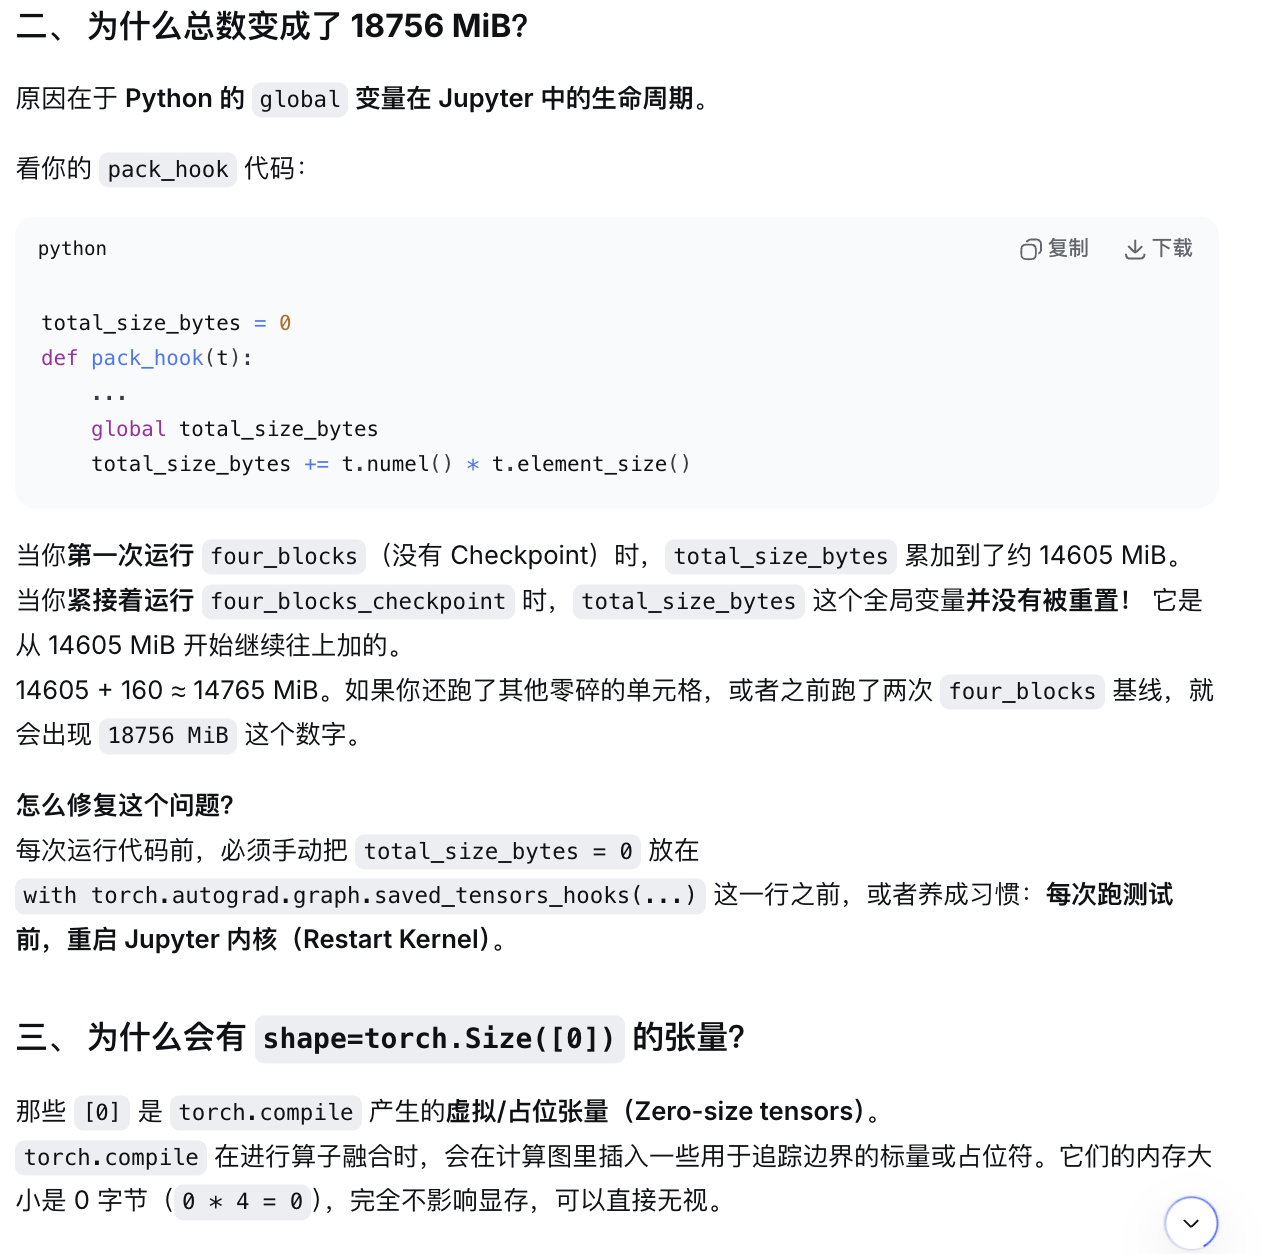

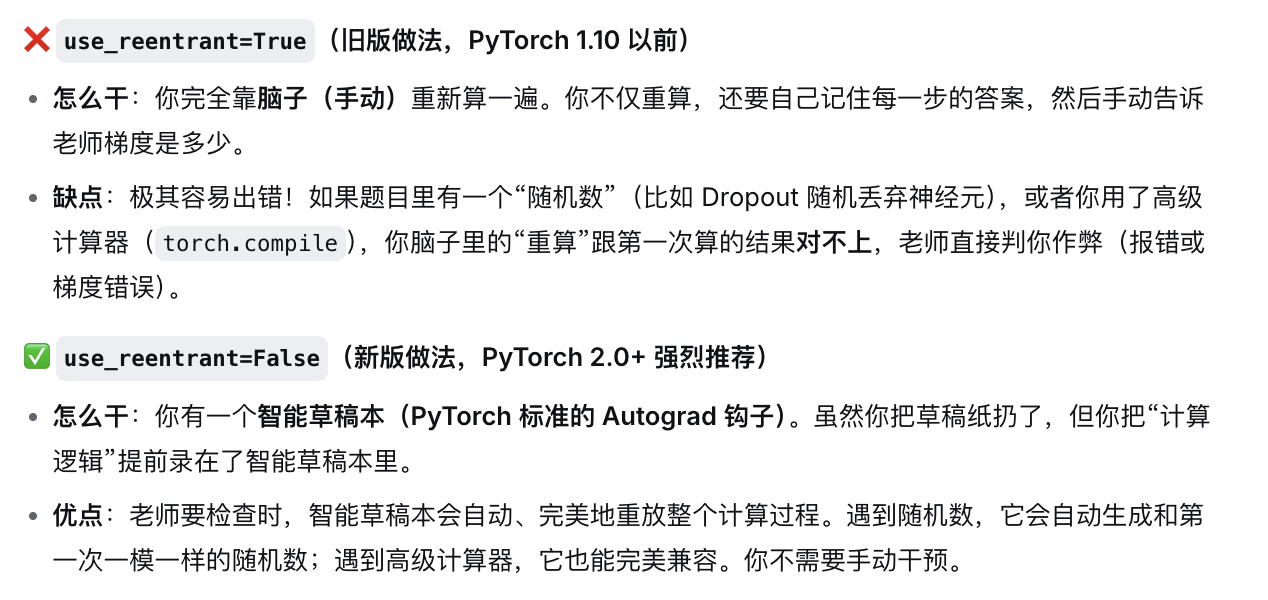
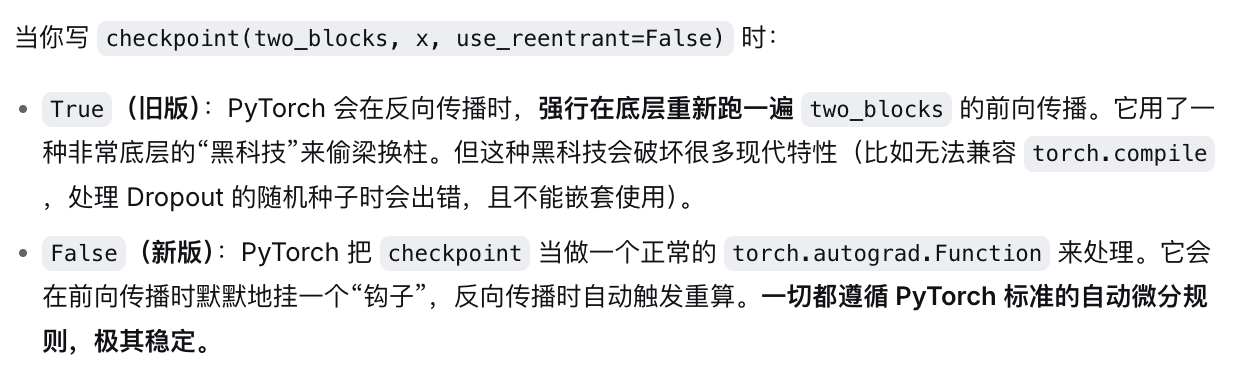

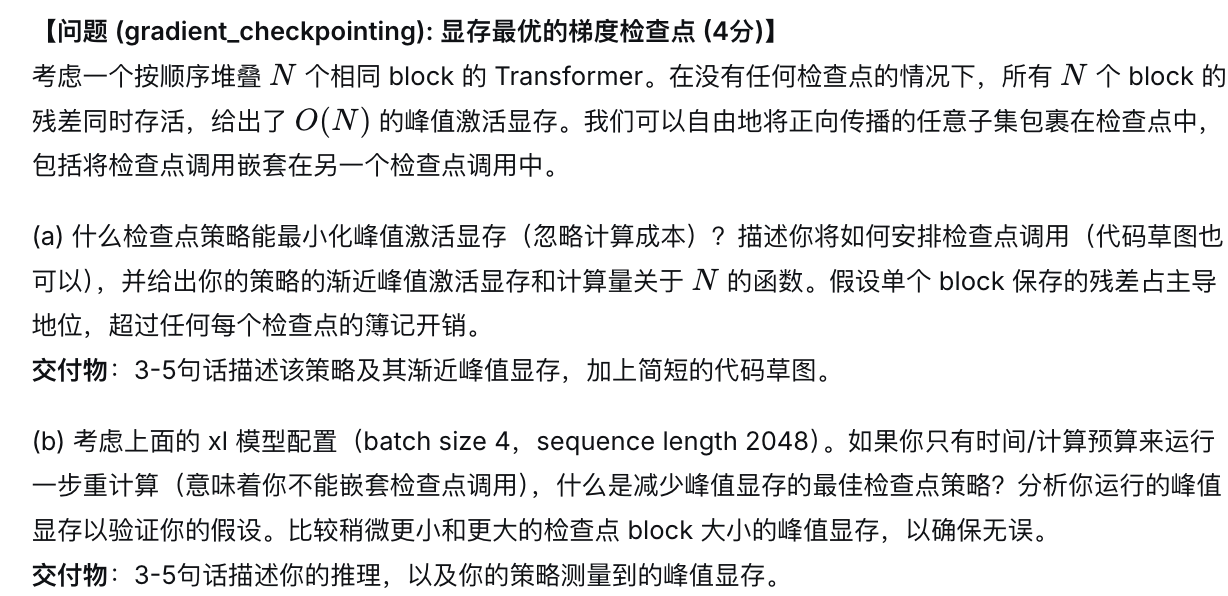

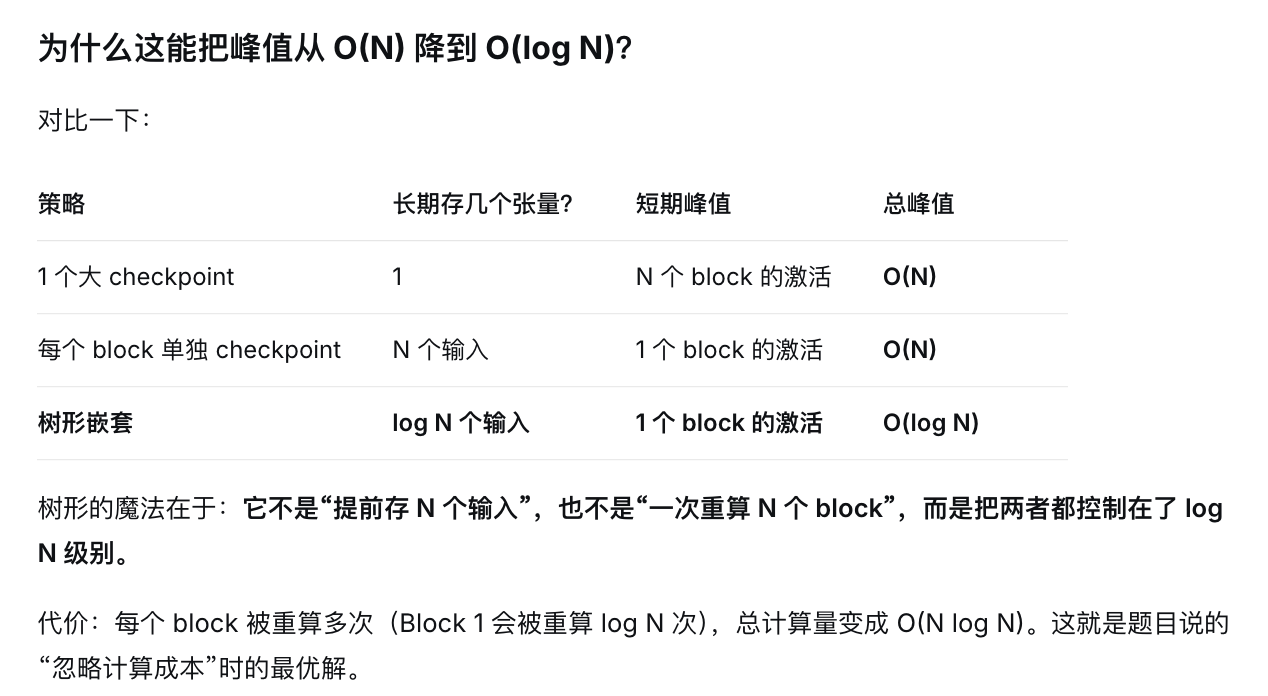